我们将复用之前的数学函数生成数据，但这次会直接将数据转换为 PyTorch 的 Tensor，并封装进 TensorDataset 和 DataLoader 中。
这是 PyTorch 处理数据的标准范式，它能在底层自动完成批次划分和数据打乱。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 1. 硬件检测
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 2. 定义目标函数并生成数据
def target_function(x):
    return np.sin(3 * np.pi * x) + 0.5 * x**2


np.random.seed(42)
num_samples = 2000
X_np = np.random.uniform(-1, 1, (num_samples, 1)).astype(np.float32)
y_np = target_function(X_np).astype(np.float32)

# 3. 转换为 PyTorch 张量
X_tensor = torch.from_numpy(X_np)
y_tensor = torch.from_numpy(y_np)

# 4. 划分训练集和测试集
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size

# 使用 random_split 随机划分
train_dataset, test_dataset = torch.utils.data.random_split(
    TensorDataset(X_tensor, y_tensor), [train_size, test_size]
)

# 5. 构建 DataLoader (设置 batch_size 为 64)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 准备画图用的平滑测试点
X_plot_np = np.linspace(-1, 1, 500).reshape(-1, 1).astype(np.float32)
X_plot_tensor = torch.from_numpy(X_plot_np).to(device)
y_plot_true = target_function(X_plot_np)

Using device: cuda


我们将构建一个极其简洁的 nn.Module。
为了对比效果，我们依然只使用一个隐藏层，包含 128 个神经元。
相比于 NumPy 版本手动推导 MSE 的导数，PyTorch 的 autograd 会在后台构建计算图并自动求导。

In [2]:
# 1. 定义两层 ReLU 神经网络
class UniversalApproximator(nn.Module):
    def __init__(self, hidden_neurons=128):
        super(UniversalApproximator, self).__init__()
        self.hidden = nn.Linear(1, hidden_neurons)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_neurons, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x


# 实例化模型并移动到 GPU
model = UniversalApproximator(hidden_neurons=128).to(device)

# 2. 定义损失函数与优化器
criterion = nn.MSELoss()
# Adam 优化器，学习率 0.01 是一个针对此类回归任务的高效起点
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. 训练循环
epochs = 500  # 得益于 Adam 和 Mini-batch，500 个 Epoch 通常足以收敛
train_losses = []

print("开始在", device, "上训练...")
for epoch in range(epochs):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        # 将数据转移到 GPU
        inputs, targets = inputs.to(device), targets.to(device)

        # 梯度清零、前向传播、计算损失、反向传播、更新参数
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    # 记录每个 Epoch 的平均损失
    epoch_loss = np.mean(batch_losses)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train MSE Loss: {epoch_loss:.6f}")

开始在 cuda 上训练...
Epoch [100/500] | Train MSE Loss: 0.021547
Epoch [200/500] | Train MSE Loss: 0.004250
Epoch [300/500] | Train MSE Loss: 0.007991
Epoch [400/500] | Train MSE Loss: 0.001026
Epoch [500/500] | Train MSE Loss: 0.001524


在测试集上计算最终损失后，我们将模型切换到 eval() 模式，并关闭梯度计算 (torch.no_grad())。
这不仅能节省显存，还会略微提升推理速度。
随后，我们绘制预测曲线，直观地感受 PyTorch 模型的分段线性逼近效果。


最终测试集 MSE: 0.001821


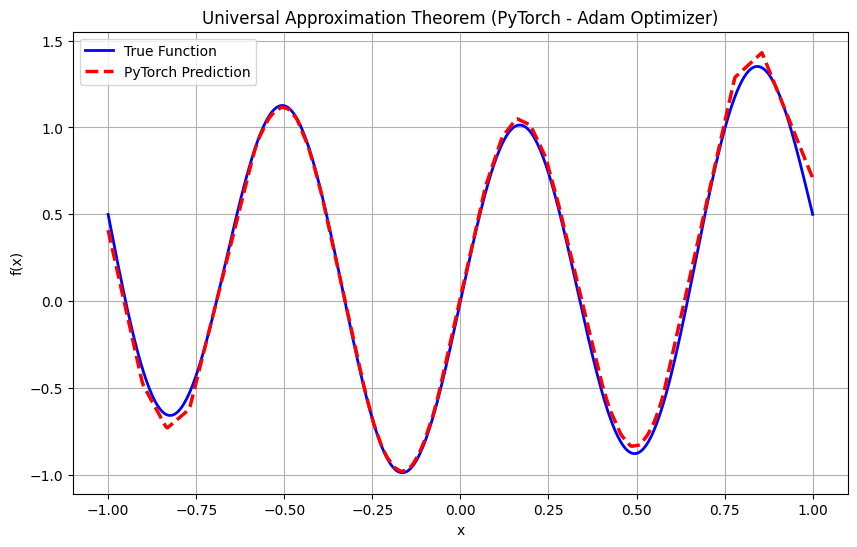

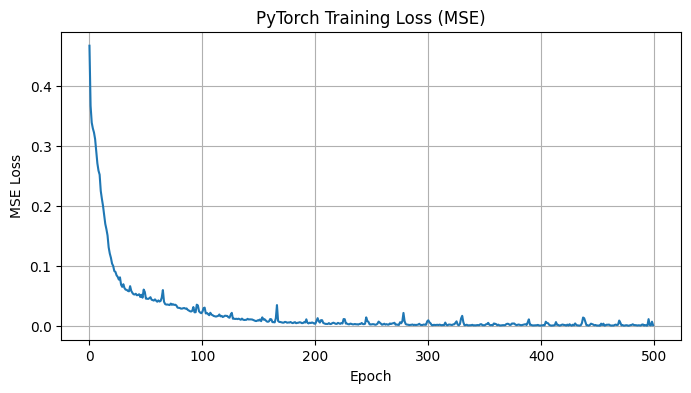

In [3]:
# 1. 在测试集上评估
model.eval()
test_losses = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

print(f"\n最终测试集 MSE: {np.mean(test_losses):.6f}")

# 2. 获取平滑曲线的预测值
with torch.no_grad():
    # 模型输出在 GPU 上，需要转移回 CPU 并转换为 NumPy 数组以便 matplotlib 画图
    y_plot_pred = model(X_plot_tensor).cpu().numpy()

# 3. 绘制拟合效果图
plt.figure(figsize=(10, 6))
plt.plot(X_plot_np, y_plot_true, label="True Function", color="blue", linewidth=2)
plt.plot(
    X_plot_np,
    y_plot_pred,
    label="PyTorch Prediction",
    color="red",
    linestyle="--",
    linewidth=2.5,
)

plt.title("Universal Approximation Theorem (PyTorch - Adam Optimizer)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 4. 绘制损失下降曲线
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("PyTorch Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()